In [60]:
# Access astronomical databases
from pyvo import registry  # version >=1.6

# Moc and HEALPix tools
from mocpy import MOC

# Sky visualization
from ipyaladin import Aladin  # version >=0.4.0

# For plots
import matplotlib.pyplot as plt

import astropy
from astropy.io import ascii
from astropy.table import Table
import pandas as pd
import numpy as np
from astroquery.simbad import Simbad

In [61]:
data = {'Name': [], 'Dist': [], 'vrec': [], 'M_Ks': [], 'M_Ks_group': [],
        'M_V': [], 'B_V': [], 'log_Mstar': [], 'r_cover': [], 
        'Data_Source': [], 'References': []}

with open('elves_hosts.dat', 'r') as f:
    lines = f.readlines()
    
for line in lines:
    cols = line.strip().split('\t')
    try:
        float(cols[1])   # only data rows have a float in column 2
        data['Name'].append(cols[0].strip())
        data['Dist'].append(float(cols[1]))
        data['vrec'].append(float(cols[2]))
        data['M_Ks'].append(float(cols[3]))
        data['M_Ks_group'].append(float(cols[4]))
        data['M_V'].append(float(cols[5]))
        data['B_V'].append(float(cols[6]))
        data['log_Mstar'].append(float(cols[7]))
        data['r_cover'].append(float(cols[8]))
        data['Data_Source'].append(cols[9].strip() if len(cols) > 9 else '')
        data['References'].append(cols[10].strip() if len(cols) > 10 else '')
    except (ValueError, IndexError):
        continue

hosts = pd.DataFrame(data)
print(hosts)

        Name   Dist    vrec   M_Ks  M_Ks_group    M_V   B_V  log_Mstar  \
0        M31   0.78  -300.0 -24.81      -24.89 -21.19  0.87      11.01   
1    NGC 253   3.56   259.0 -23.95      -23.96 -20.70  0.94      10.77   
2    NGC 628   9.77   656.0 -22.79      -22.81 -20.68  0.48      10.45   
3    NGC 891   9.12   528.0 -23.83      -23.83 -20.05  0.82      10.84   
4   NGC 1023  10.40   638.0 -23.78      -23.98 -20.91  0.95      10.60   
5   NGC 1291   9.08   838.0 -23.94      -23.97 -21.01  1.00      10.78   
6   NGC 1808   9.29  1002.0 -23.12      -23.78 -19.98  0.79      10.01   
7   NGC 2683   9.40   409.0 -23.49      -23.50 -20.17  0.86      10.50   
8   NGC 2903   9.00   556.0 -23.68      -23.69 -20.78  0.65      10.67   
9        M81   3.61   -42.0 -23.89      -25.27 -21.07  0.88      10.66   
10  NGC 3115  10.20   666.0 -24.12      -24.14 -21.27  0.93      10.76   
11  NGC 3344   9.82   585.0 -22.27      -22.27 -20.19  0.65      10.27   
12  NGC 3379  10.70   876.0 -23.80    

In [62]:
hosts["Name"] = hosts["Name"].str.replace(" ", "")
host_id_direct = np.array(hosts["Name"])
print(host_id_direct)

['M31' 'NGC253' 'NGC628' 'NGC891' 'NGC1023' 'NGC1291' 'NGC1808' 'NGC2683'
 'NGC2903' 'M81' 'NGC3115' 'NGC3344' 'NGC3379' 'NGC3521' 'NGC3556'
 'NGC3621' 'NGC3627' 'NGC4258' 'NGC4517' 'NGC4565' 'M104' 'NGC4631'
 'NGC4736' 'NGC4826' 'NGC5055' 'CENA' 'NGC5194' 'NGC5236' 'NGC5457'
 'NGC6744' 'MW']


In [63]:
# each resource in the VO has an identifier, called ivoid. For vizier catalogs,
# the VO ids can be constructed like this:
# the catalogue name in VizieR
CATALOGUE = "J/ApJ/933/47"
catalogue_ivoid = f"ivo://CDS.VizieR/{CATALOGUE}"
# the actual query to the registry
voresource = registry.search(ivoid=catalogue_ivoid)[0]
tables = voresource.get_tables()
print(f"In this catalogue, we have {len(tables)} tables.")
for table_name, table in tables.items():
    print(f"{table_name}: {table.description}")
    # We can also extract the tables names for later use
tables_names = list(tables.keys())
tables_names

In this catalogue, we have 5 tables.
J/ApJ/933/47/table6: Confirmed dwarf satellite distance results
J/ApJ/933/47/table7: Rejected background contaminants distance results
J/ApJ/933/47/table8: Unconfirmed/possible candidate satellites
J/ApJ/933/47/table9: Satellite photometry
J/ApJ/933/47/table10: GALEX photometry for confirmed satellites


['J/ApJ/933/47/table6',
 'J/ApJ/933/47/table7',
 'J/ApJ/933/47/table8',
 'J/ApJ/933/47/table9',
 'J/ApJ/933/47/table10']

In [157]:
colnames = ["Name","Host","RAdeg","DEdeg","Rproj","gmag","e_gmag","rimag","e_rimag","gMag","VMag","e_VMag","logMs","e_logMs","mu0V","e_mu0V","re","e_re","ETG","Conf","Psat","Filt","Tel","Bad"]

table9 = pd.read_fwf(
    '/Users/olgahinke/Desktop/elves_sats/table9.dat',
    names=colnames,
    header=None
)

# convert numeric columns
for col in ["RAdeg","DEdeg","Rproj","gmag","e_gmag","rimag","e_rimag","gMag","VMag","e_VMag","logMs","e_logMs","mu0V","e_mu0V","re","e_re", "Psat"]:
    table9[col] = pd.to_numeric(table9[col], errors='coerce')
hosts_tab9 = np.array(table9["Host"])

In [65]:
colnames = ["Name","Host","RAdeg","DEdeg","l_NUVmag", "NUVmag", "e_NUVmag", "l_FUVmag", "FUVmag","e_FUVmag" , "GALEX"]
table10 = pd.read_fwf(
    '/Users/olgahinke/Desktop/elves_sats/table10.dat',
    names=colnames,
    header=None
)

# convert numeric columns
for col in ["RAdeg","DEdeg", "NUVmag", "e_NUVmag", "FUVmag","e_FUVmag"]:
    table10[col] = pd.to_numeric(table10[col], errors='coerce')
print(table10)
hosts_tab10 = np.array(table10["Host"])

            Name     Host     RAdeg    DEdeg l_NUVmag  NUVmag  e_NUVmag  \
0    dw0047m2623   NGC253   11.8939 -26.3898   >22.08     NaN       NaN   
1    dw0049m2100   NGC253   12.4537 -21.0167    16.74    0.05     16.97   
2    dw0055m2309   NGC253   13.7538 -23.1688    18.93    0.07     19.17   
3    dw0133p1543   NGC628   23.4842  15.7314   >22.45     NaN       NaN   
4    dw0134p1544   NGC628   23.5537  15.7463    20.65    0.16       NaN   
..           ...      ...       ...      ...      ...     ...       ...   
266  dw1905m6316  NGC6744  286.4831 -63.2721    21.81    0.45       NaN   
267  dw1906m6357  NGC6744  286.7415 -63.9636    20.43    0.12       NaN   
268  dw1907m6342  NGC6744  286.8439 -63.7064    21.53    0.11       NaN   
269  dw1908m6343  NGC6744  287.1830 -63.7301    16.17    0.05     16.41   
270  dw1911m6413  NGC6744  287.8437 -64.2226    16.70    0.05     17.29   

     l_FUVmag  FUVmag  e_FUVmag  GALEX  
0         NaN     NaN       NaN    NaN  
1        0.05    

In [66]:
colnames = ['Name', 'RAdeg', 'DEdeg', 'Host', 'D_Host', 'D_SBF', 
            'lb2Dist', 'lb1Dist', 'ub1Dist', 'ub2Dist', 'SNR', 
            'Tel', 'Conf', 'vrec', 'r_vrec', 'D_trgb', 'r_trgb']

table6 = pd.read_fwf(
    '/Users/olgahinke/Desktop/elves_sats/table6.dat',
    names=colnames,
    header=None
)

# convert numeric columns
for col in ['RAdeg', 'DEdeg', 'D_Host', 'D_SBF', 'lb2Dist', 'lb1Dist',
            'ub1Dist', 'ub2Dist', 'SNR', 'vrec', 'D_trgb']:
    table6[col] = pd.to_numeric(table6[col], errors='coerce')

print(table6)
hosts_tab6 = np.array(table6["Host"])

            Name    RAdeg   DEdeg     Host  D_Host  D_SBF  lb2Dist  lb1Dist  \
0         NGC247   11.783 -20.757   NGC253    3.56    NaN      NaN      NaN   
1    dw0047m2623   11.894 -26.390   NGC253    3.56    NaN      NaN      NaN   
2    dw0049m2100   12.454 -21.017   NGC253    3.56    NaN      NaN      NaN   
3    dw0050m2444   12.575 -24.737   NGC253    3.56    NaN      NaN      NaN   
4    dw0055m2309   13.754 -23.169   NGC253    3.56    NaN      NaN      NaN   
..           ...      ...     ...      ...     ...    ...      ...      ...   
246  dw1905m6316  286.483 -63.272  NGC6744    8.95   7.61     5.57     6.55   
247  dw1906m6357  286.742 -63.964  NGC6744    8.95   7.31     5.55     6.44   
248  dw1907m6342  286.844 -63.706  NGC6744    8.95   7.99     6.26     7.12   
249  dw1908m6343  287.183 -63.730  NGC6744    8.95   5.33     4.35     4.80   
250  dw1911m6413  287.844 -64.223  NGC6744    8.95    NaN      NaN      NaN   

     ub1Dist  ub2Dist    SNR    Tel   Conf   vrec r

In [67]:
host_names_tab6 = []
for i in range(0,len(hosts_tab6)):
    print("Iteration", i)
    curr = hosts_tab6[i]
    if i == 0:
        host_names_tab6.append(curr)
    else:
        if curr == host_names_tab6[-1]:
            print(".not a new name")
            pass
        else:
            print(".a new name!")
            if curr in host_names_tab6:
                print("..found already in list!")
                pass
            else:
                print("...really a new name!!!")
                host_names_tab6.append(curr)
    print("Number of unique galaxies:", len(host_names_tab6))

Iteration 0
Number of unique galaxies: 1
Iteration 1
.not a new name
Number of unique galaxies: 1
Iteration 2
.not a new name
Number of unique galaxies: 1
Iteration 3
.not a new name
Number of unique galaxies: 1
Iteration 4
.not a new name
Number of unique galaxies: 1
Iteration 5
.a new name!
...really a new name!!!
Number of unique galaxies: 2
Iteration 6
.not a new name
Number of unique galaxies: 2
Iteration 7
.not a new name
Number of unique galaxies: 2
Iteration 8
.not a new name
Number of unique galaxies: 2
Iteration 9
.not a new name
Number of unique galaxies: 2
Iteration 10
.not a new name
Number of unique galaxies: 2
Iteration 11
.not a new name
Number of unique galaxies: 2
Iteration 12
.not a new name
Number of unique galaxies: 2
Iteration 13
.not a new name
Number of unique galaxies: 2
Iteration 14
.not a new name
Number of unique galaxies: 2
Iteration 15
.not a new name
Number of unique galaxies: 2
Iteration 16
.not a new name
Number of unique galaxies: 2
Iteration 17
.not a

In [68]:
host_names_tab9 = []
for i in range(0,len(hosts_tab9)):
    print("Iteration", i)
    curr = hosts_tab9[i]
    if i == 0:
        host_names_tab9.append(curr)
    else:
        if curr == host_names_tab9[-1]:
            print(".not a new name")
            pass
        else:
            print(".a new name!")
            if curr in host_names_tab9:
                print("..found already in list!")
                pass
            else:
                print("...really a new name!!!")
                host_names_tab9.append(curr)
    print("Number of unique galaxies:", len(host_names_tab9))

Iteration 0
Number of unique galaxies: 1
Iteration 1
.not a new name
Number of unique galaxies: 1
Iteration 2
.not a new name
Number of unique galaxies: 1
Iteration 3
.not a new name
Number of unique galaxies: 1
Iteration 4
.not a new name
Number of unique galaxies: 1
Iteration 5
.not a new name
Number of unique galaxies: 1
Iteration 6
.not a new name
Number of unique galaxies: 1
Iteration 7
.not a new name
Number of unique galaxies: 1
Iteration 8
.not a new name
Number of unique galaxies: 1
Iteration 9
.not a new name
Number of unique galaxies: 1
Iteration 10
.not a new name
Number of unique galaxies: 1
Iteration 11
.not a new name
Number of unique galaxies: 1
Iteration 12
.not a new name
Number of unique galaxies: 1
Iteration 13
.not a new name
Number of unique galaxies: 1
Iteration 14
.not a new name
Number of unique galaxies: 1
Iteration 15
.not a new name
Number of unique galaxies: 1
Iteration 16
.not a new name
Number of unique galaxies: 1
Iteration 17
.not a new name
Number of u

In [69]:
for i in host_id_direct: 
    if i in host_names_tab9:
        print(i, ":all good")
    else:
        print(i, ":missing!!!")

M31 :all good
NGC253 :all good
NGC628 :all good
NGC891 :all good
NGC1023 :all good
NGC1291 :all good
NGC1808 :all good
NGC2683 :all good
NGC2903 :all good
M81 :all good
NGC3115 :all good
NGC3344 :all good
NGC3379 :all good
NGC3521 :all good
NGC3556 :all good
NGC3621 :missing!!!
NGC3627 :all good
NGC4258 :all good
NGC4517 :all good
NGC4565 :all good
M104 :all good
NGC4631 :all good
NGC4736 :all good
NGC4826 :all good
NGC5055 :all good
CENA :all good
NGC5194 :all good
NGC5236 :all good
NGC5457 :all good
NGC6744 :all good
MW :all good


In [70]:
sats_without_distances = []
for i in np.array(table9["Name"]):
    if i in np.array(table6["Name"]):
        pass
    else:
        print(i, ":missing!!!")
        sats_without_distances.append(i)
        
print(len(sats_without_distances), "satellites not matched in table6")
print(len(np.array(table9["Name"])) - len(np.array(table6["Name"])))

M33 :missing!!!
NGC205 :missing!!!
M32 :missing!!!
NGC147 :missing!!!
IC10 :missing!!!
NGC185 :missing!!!
andVII :missing!!!
andXXXII :missing!!!
andII :missing!!!
andI :missing!!!
andXXXI :missing!!!
andIII :missing!!!
andXXIII :missing!!!
andVI :missing!!!
andXXI :missing!!!
andXXV :missing!!!
LGS3 :missing!!!
andXV :missing!!!
andV :missing!!!
andXVIII :missing!!!
dw0036m2828 :missing!!!
dw0141p1651 :missing!!!
dw0223p4314 :missing!!!
dw0224p4158 :missing!!!
dw0225p4153 :missing!!!
dw0226p4206 :missing!!!
dw0238p3805 :missing!!!
dw0241p3829 :missing!!!
dw0243p3915 :missing!!!
dw0312m3955 :missing!!!
dw0315m4112 :missing!!!
dw0316m4207 :missing!!!
dw0321m4149 :missing!!!
dw0502m3845 :missing!!!
dw0506m3800 :missing!!!
dw0507m3733 :missing!!!
dw0510m3717 :missing!!!
dw0846p3300 :missing!!!
dw0846p3348 :missing!!!
dw0852p3249 :missing!!!
dw0854p3314 :missing!!!
M82 :missing!!!
NGC3077 :missing!!!
NGC2976 :missing!!!
IC2574 :missing!!!
ddo82 :missing!!!
kdg61 :missing!!!
BK5N :missing!!

In [71]:
no_hosts_with_distance = []
for i in host_names_tab9:
    if i in host_names_tab6:
        pass
    else:
        #print(i, ":missing!!!")
        no_hosts_with_distance.append(i)
print("Not matched:", no_hosts_with_distance)

Not matched: ['M31', 'M81', 'CENA', 'NGC5236', 'MW']


In [72]:
host_dec_simbad = []
host_ra_simbad = []

for i in host_id_direct:
    result_table = Simbad.query_object(f"{i}")
    if len(result_table) > 0:
        ra = result_table["ra"][0]
        dec = result_table["dec"][0]
        host_dec_simbad.append(dec)
        host_ra_simbad.append(ra)
        print(f"{i}, {ra}, {dec}")
        
    else:
        print(f"{i} NOT worked")
        host_dec_simbad.append("NaN")
        host_ra_simbad.append("NaN")

M31, 10.684708333333333, 41.268750000000004
NGC253, 11.888058333333333, -25.288800000000002
NGC628, 24.173938015259996, 15.783640975640001
NGC891, 35.6371125, 42.34831944444444
NGC1023, 40.10005565661, 39.063239831359994
NGC1291, 49.32741063948, -41.10795242644001
NGC1808, 76.92642916666667, -37.51305000000001
NGC2683, 133.17211034566, 33.42183268931
NGC2903, 143.04212916666668, 21.500830555555552
M81, 148.88821939854, 69.06529514038
NGC3115, 151.30802937792, -7.718606308970001
NGC3344, 160.87979166666668, 24.92221944444444
NGC3379, 161.95666666666665, 12.581630555555554
NGC3521, 166.45236707974, -0.03590141015
NGC3556, 167.87902916666664, 55.67412222222222
NGC3621, 169.5679166666667, -32.8126
NGC3627, 170.0626, 12.9915
NGC4258, 184.7400833333333, 47.30371944444444
NGC4517, 188.1899416666666, 0.1150388888888889
NGC4565, 189.0866833333333, 25.987391666666667
M104, 189.99763274591663, -11.623054494444448
NGC4631, 190.53337083333332, 32.541511111111106
NGC4736, 192.72114082143, 41.1202502

Hosts: 
- RA/DEC
- Distance 
- vrec
- Masse (Halo, star, HI gas) -> log(M_star) 
- Magnitude? M_ks ? 
- sersic 
- nsats (taking highest values from photometry)

Sats: 
- Host id 
- distance 
- RA/DEC
- vrec relative to host
- masse 
- magnitude 
- sersic index/radius


In [73]:
n_sat_9 = []
for i in host_names_tab9:
    satellites = table9[table9["Host"] == i]
    print(f"Host: {i}, Number of satellites: {len(satellites)}")
    n_sat_9.append(len(satellites))


Host: M31, Number of satellites: 20
Host: NGC253, Number of satellites: 6
Host: NGC628, Number of satellites: 14
Host: NGC891, Number of satellites: 7
Host: NGC1023, Number of satellites: 17
Host: NGC1291, Number of satellites: 18
Host: NGC1808, Number of satellites: 14
Host: NGC2683, Number of satellites: 10
Host: NGC2903, Number of satellites: 7
Host: M81, Number of satellites: 24
Host: NGC3115, Number of satellites: 19
Host: NGC3344, Number of satellites: 7
Host: NGC3379, Number of satellites: 66
Host: NGC3521, Number of satellites: 12
Host: NGC3556, Number of satellites: 14
Host: NGC3627, Number of satellites: 32
Host: NGC4258, Number of satellites: 8
Host: NGC4517, Number of satellites: 9
Host: NGC4565, Number of satellites: 9
Host: M104, Number of satellites: 15
Host: NGC4631, Number of satellites: 13
Host: NGC4736, Number of satellites: 14
Host: NGC4826, Number of satellites: 9
Host: NGC5055, Number of satellites: 14
Host: CENA, Number of satellites: 22
Host: NGC5194, Number of 

In [74]:
n_sat_6 = []
for i in host_names_tab6:
    satellites = table6[table6["Host"] == i]
    print(f"Host: {i}, Number of satellites: {len(satellites)}")
    n_sat_6.append(len(satellites)) 
print(len(n_sat_6))

Host: NGC253, Number of satellites: 5
Host: NGC628, Number of satellites: 13
Host: NGC891, Number of satellites: 3
Host: NGC1023, Number of satellites: 14
Host: NGC1291, Number of satellites: 14
Host: NGC1808, Number of satellites: 10
Host: NGC2683, Number of satellites: 6
Host: NGC2903, Number of satellites: 7
Host: NGC3115, Number of satellites: 17
Host: NGC3344, Number of satellites: 3
Host: NGC3379, Number of satellites: 44
Host: NGC3521, Number of satellites: 11
Host: NGC3556, Number of satellites: 1
Host: NGC3627, Number of satellites: 20
Host: NGC4258, Number of satellites: 7
Host: NGC4517, Number of satellites: 9
Host: NGC4565, Number of satellites: 4
Host: M104, Number of satellites: 11
Host: NGC4631, Number of satellites: 12
Host: NGC4736, Number of satellites: 7
Host: NGC4826, Number of satellites: 7
Host: NGC5055, Number of satellites: 9
Host: NGC5194, Number of satellites: 3
Host: NGC5457, Number of satellites: 9
Host: NGC6744, Number of satellites: 5
25


In [75]:
def radec_dist_to_cartesian(ra_deg, dec_deg, dist_Mpc):
    """
    Convert RA, Dec, distance to heliocentric Cartesian [Mpc].
    Standard equatorial Cartesian: x toward (0,0), y toward (90,0), z toward N pole
    """
    ra  = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    x = dist_Mpc * np.cos(dec) * np.cos(ra)
    y = dist_Mpc * np.cos(dec) * np.sin(ra)
    z = dist_Mpc * np.sin(dec)
    return np.array([x, y, z])

def host_centred_coords(ra_sat, dec_sat, dist_sat_Mpc,
                        ra_host, dec_host, dist_host_Mpc):
    """
    Satellite position in host-centred Cartesian frame [kpc].

    If dist_sat_Mpc is unknown, pass dist_host_Mpc for the satellite
    (projected distance assumption).
    """
    r_sat  = radec_dist_to_cartesian(ra_sat,  dec_sat,  dist_sat_Mpc)
    r_host = radec_dist_to_cartesian(ra_host, dec_host, dist_host_Mpc)

    r_rel_Mpc = r_sat - r_host
    r_rel_kpc = r_rel_Mpc * 1e3

    return r_rel_kpc   # (x, y, z) in kpc, host at origin


In [77]:
print(table6)

            Name    RAdeg   DEdeg     Host  D_Host  D_SBF  lb2Dist  lb1Dist  \
0         NGC247   11.783 -20.757   NGC253    3.56    NaN      NaN      NaN   
1    dw0047m2623   11.894 -26.390   NGC253    3.56    NaN      NaN      NaN   
2    dw0049m2100   12.454 -21.017   NGC253    3.56    NaN      NaN      NaN   
3    dw0050m2444   12.575 -24.737   NGC253    3.56    NaN      NaN      NaN   
4    dw0055m2309   13.754 -23.169   NGC253    3.56    NaN      NaN      NaN   
..           ...      ...     ...      ...     ...    ...      ...      ...   
246  dw1905m6316  286.483 -63.272  NGC6744    8.95   7.61     5.57     6.55   
247  dw1906m6357  286.742 -63.964  NGC6744    8.95   7.31     5.55     6.44   
248  dw1907m6342  286.844 -63.706  NGC6744    8.95   7.99     6.26     7.12   
249  dw1908m6343  287.183 -63.730  NGC6744    8.95   5.33     4.35     4.80   
250  dw1911m6413  287.844 -64.223  NGC6744    8.95    NaN      NaN      NaN   

     ub1Dist  ub2Dist    SNR    Tel   Conf   vrec r

In [105]:
hosts["Name_nospace"] = hosts["Name"].str.replace(" ", "")

table6_with_host = pd.merge(
    table6,
    hosts[["Name_nospace", "vrec"]].rename(columns={
        "Name_nospace": "Host", 
        "vrec": "vrec_host"
    }),
    on="Host",
    how="left"
)

table6_with_host["vrec_rel"] = table6_with_host["vrec"] - table6_with_host["vrec_host"]

print(table6_with_host[["Name", "Host", "vrec", "vrec_host", "vrec_rel"]])

            Name     Host   vrec  vrec_host  vrec_rel
0         NGC247   NGC253  159.0      259.0    -100.0
1    dw0047m2623   NGC253    NaN      259.0       NaN
2    dw0049m2100   NGC253  295.0      259.0      36.0
3    dw0050m2444   NGC253    NaN      259.0       NaN
4    dw0055m2309   NGC253  250.0      259.0      -9.0
..           ...      ...    ...        ...       ...
246  dw1905m6316  NGC6744    NaN      839.0       NaN
247  dw1906m6357  NGC6744    NaN      839.0       NaN
248  dw1907m6342  NGC6744    NaN      839.0       NaN
249  dw1908m6343  NGC6744    NaN      839.0       NaN
250  dw1911m6413  NGC6744  779.0      839.0     -60.0

[251 rows x 5 columns]


In [79]:
print(hosts)

       Name   Dist    vrec   M_Ks  M_Ks_group    M_V   B_V  log_Mstar  \
0       M31   0.78  -300.0 -24.81      -24.89 -21.19  0.87      11.01   
1    NGC253   3.56   259.0 -23.95      -23.96 -20.70  0.94      10.77   
2    NGC628   9.77   656.0 -22.79      -22.81 -20.68  0.48      10.45   
3    NGC891   9.12   528.0 -23.83      -23.83 -20.05  0.82      10.84   
4   NGC1023  10.40   638.0 -23.78      -23.98 -20.91  0.95      10.60   
5   NGC1291   9.08   838.0 -23.94      -23.97 -21.01  1.00      10.78   
6   NGC1808   9.29  1002.0 -23.12      -23.78 -19.98  0.79      10.01   
7   NGC2683   9.40   409.0 -23.49      -23.50 -20.17  0.86      10.50   
8   NGC2903   9.00   556.0 -23.68      -23.69 -20.78  0.65      10.67   
9       M81   3.61   -42.0 -23.89      -25.27 -21.07  0.88      10.66   
10  NGC3115  10.20   666.0 -24.12      -24.14 -21.27  0.93      10.76   
11  NGC3344   9.82   585.0 -22.27      -22.27 -20.19  0.65      10.27   
12  NGC3379  10.70   876.0 -23.80      -25.37 -20.4

In [130]:
# ── count satellites per host in each table ───────────────────────────────────
n_sat_6 = table6.groupby("Host").size().reset_index(name="n_sat_table6")
n_sat_9 = table9.groupby("Host").size().reset_index(name="n_sat_table9")
host_table = hosts.copy()
host_table = pd.merge(host_table, 
                      n_sat_6[["Host", "n_sat_table6"]],
                      left_on="Name", right_on="Host",
                      how="left").drop(columns="Host")

host_table = pd.merge(host_table,
                      n_sat_9[["Host", "n_sat_table9"]],
                      left_on="Name", right_on="Host",
                      how="left").drop(columns="Host")

all_sats = pd.concat([
    table6[["Name", "Host"]],
    table9[["Name", "Host"]]
]).drop_duplicates(subset="Name")

n_sat_total = all_sats.groupby("Host").size().reset_index(name="n_sat_total")
n_sat_total["Host"] = n_sat_total["Host"].str.replace(" ", "")
host_table = pd.merge(host_table,
                      n_sat_total[["Host", "n_sat_total"]],
                      left_on="Name_nospace", right_on="Host",
                      how="left").drop(columns="Host")

host_table["n_sat_total"] = host_table["n_sat_total"].fillna(0).astype(int)

print(host_table[["Name", "n_sat_table6", "n_sat_table9", "n_sat_total"]])


       Name  n_sat_table6  n_sat_table9  n_sat_total
0       M31           NaN          20.0           20
1    NGC253           5.0           6.0            6
2    NGC628          13.0          14.0           14
3    NGC891           3.0           7.0            7
4   NGC1023          14.0          17.0           17
5   NGC1291          14.0          18.0           18
6   NGC1808          10.0          14.0           14
7   NGC2683           6.0          10.0           10
8   NGC2903           7.0           7.0            7
9       M81           NaN          24.0           24
10  NGC3115          17.0          19.0           19
11  NGC3344           3.0           7.0            7
12  NGC3379          44.0          66.0           66
13  NGC3521          11.0          12.0           12
14  NGC3556           1.0          14.0           14
15  NGC3621           NaN           NaN            0
16  NGC3627          20.0          32.0           32
17  NGC4258           7.0           8.0       

In [186]:
from astropy.table import join
from astropy.table import Table, MaskedColumn
from astropy.io import ascii
from astropy import units as u
# read your two ascii tables
import pandas as pd

t_host = Table()
t_host['Name'] = host_table['Name']
t_host['Name'] = np.array(t_host['Name'], dtype=str)
t_host['RAdeg']    = np.array(host_ra_simbad).astype(float)
t_host['DEdeg']    = np.array(host_dec_simbad).astype(float)
t_host['Dist']    = host_table['Dist']
t_host['vrec']    = host_table['vrec']
t_host['logMs']    = host_table['log_Mstar']
t_host['nsat']    = host_table['n_sat_total']
t_host['Source']     = np.full(len(host_table), '2022ApJ...933...47C', dtype='<U20')

# ── units ─────────────────────────────────────────────────────────────────────
t_host['RAdeg'].unit   = u.deg
t_host['DEdeg'].unit   = u.deg
t_host['Dist'].unit = u.Mpc
t_host['vrec'].unit    = u.km/u.s
t_host['logMs'].unit   = u.dex(u.Msun)

# ── descriptions ──────────────────────────────────────────────────────────────
t_host['Name'].description    = "Host name"
t_host['RAdeg'].description   = "Right ascension from Simbad"
t_host['DEdeg'].description   = "Declination from Simbad"
t_host['Dist'].description = "Distance to Host"
t_host['logMs'].description   = "log10 stellar mass"
t_host['vrec'].description    = "Heliocentric recessional velocity "
t_host['nsat'].description    = "Number of satellites"
t_host['Source'].description   = "Source of the host data"
# ── mask NaN values for MRT writer ───────────────────────────────────────────
for col in t_host.colnames:
    if t_host[col].dtype == float:
        t_host[col] = MaskedColumn(t_host[col], mask=np.isnan(t_host[col]))
        
ascii.write(t_host, 'elves_hosts.mrt',
            format='mrt',
            overwrite=True)
full_hosts = ascii.read('elves_hosts.mrt', format='mrt')

In [184]:
t1 = ascii.read('elves_hosts.mrt', format='mrt')
t2 = ascii.read('saga_hosts.mrt', format='mrt')
from astropy.table import vstack
combined = vstack([t1, t2], join_type='outer')
ascii.write(combined, 'hosts.mrt', format='mrt', overwrite=True)
new_order = ['Name',
 'RAdeg',
 'DEdeg',
  'Dist',
'vrec',
 'logMs',
 'sb',
  "ba",
 "PA",
'Sersic',
 "nsat",
'Source',]

combined = combined[new_order]
ascii.write(combined, 'hosts.mrt', format='mrt', overwrite=True)
ascii.read('hosts.mrt', format='mrt')

Name,RAdeg,DEdeg,Dist,vrec,logMs,sb,ba,PA,Sersic,nsat,Source
,deg,deg,Mpc,km / s,dex(solMass),mag / arcsec2,,deg,,,
str10,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,str19
M31,10.684708333333333,41.268750000000004,0.78,-300.0,11.01,--,--,--,--,20,2022ApJ...933...47C
NGC253,11.888058333333333,-25.288800000000002,3.56,259.0,10.77,--,--,--,--,6,2022ApJ...933...47C
NGC628,24.173938015259996,15.783640975640001,9.77,656.0,10.45,--,--,--,--,14,2022ApJ...933...47C
NGC891,35.6371125,42.34831944444444,9.12,528.0,10.84,--,--,--,--,7,2022ApJ...933...47C
NGC1023,40.10005565661,39.063239831359994,10.4,638.0,10.6,--,--,--,--,17,2022ApJ...933...47C
NGC1291,49.32741063948,-41.10795242644001,9.08,838.0,10.78,--,--,--,--,18,2022ApJ...933...47C
NGC1808,76.92642916666667,-37.51305000000001,9.29,1002.0,10.01,--,--,--,--,14,2022ApJ...933...47C
NGC2683,133.17211034566,33.42183268931,9.4,409.0,10.5,--,--,--,--,10,2022ApJ...933...47C


In [206]:

# ── merge the two tables on Name ──────────────────────────────────────────────
# keep all satellites from table9, add distance/vrec from table6 where available
merged = pd.merge(
    table9[["Name", "Host", "RAdeg", "DEdeg", "logMs", "e_logMs", "mu0V", "e_mu0V", "re", "e_re", "Conf"]],
    table6_with_host[["Name", "vrec_rel", "D_SBF", "D_trgb"]],
    on="Name",
    how="left"    # NaN for satellites not in table6
)
# ── build astropy table ───────────────────────────────────────────────────────
t = Table()
t['Name'] = merged['Name'].to_numpy(dtype=str)
t['Host'] = merged['Host'].to_numpy(dtype=str)
t['RAdeg']    = merged['RAdeg'].values.astype(float)
t['DEdeg']    = merged['DEdeg'].values.astype(float)
#t["x"] = 
#t["y"] = 
t['logMs']    = merged['logMs'].values.astype(float)
t['e_logMs']  = merged['e_logMs'].values.astype(float)
t['mu0V']     = merged['mu0V'].values.astype(float)
t['e_mu0V']   = merged['e_mu0V'].values.astype(float)
t['vrec']     = merged['vrec_rel'].values.astype(float)
t['re']     = merged['re'].values.astype(float)
t['e_re']     = merged['e_re'].values.astype(float)
t['D_SBF']    = merged['D_SBF'].values.astype(float)
t['D_trgb']   = merged['D_trgb'].values.astype(float)
t['Conf']     = merged['Conf'].values.astype(float)
t['Source']     = np.full(len(merged), '2022ApJ...933...47C', dtype='<U20')

# ── units ─────────────────────────────────────────────────────────────────────
t['RAdeg'].unit   = u.deg
t['DEdeg'].unit   = u.deg
t['vrec'].unit    = u.km/u.s
t["re"].unit = u.pc
t["e_re"].unit = u.pc
t['D_SBF'].unit   = u.Mpc
t['D_trgb'].unit  = u.Mpc
t['mu0V'].unit    = u.mag/u.arcsec**2
t['e_mu0V'].unit  = u.mag/u.arcsec**2
t['logMs'].unit   = u.dex(u.Msun)
t['e_logMs'].unit = u.dex(u.Msun)

# ── descriptions ──────────────────────────────────────────────────────────────
t['Name'].description    = "Satellite name"
t['Host'].description    = "Host galaxy"
t['RAdeg'].description   = "Right ascension (deg)"
t['DEdeg'].description   = "Declination (deg)"
t['logMs'].description   = "log10 stellar mass [Msun]"
t['e_logMs'].description = "Uncertainty in log10 stellar mass"
t['mu0V'].description    = "V-band surface brightness"
t['e_mu0V'].description  = "Uncertainty in V-band surface brightness"
t['vrec'].description    = "Difference in heliocentric recessional velocity in relation to host"
t['re'].description    = "Effective radius"
t['e_re'].description    = "Error in effective radius"
t['D_SBF'].description   = "Distance from surface brightness fluctuations"
t['D_trgb'].description  = "Distance from tip of red giant branch"
t['Conf'].description   = "Confirmed Satellite (1=confirmed, 0=unconfirmed)"
t['Source'].description   = "Source of the satellite data"

# ── mask NaN values for MRT writer ───────────────────────────────────────────
for col in t.colnames:
    if t[col].dtype == float:
        t[col] = MaskedColumn(t[col], mask=np.isnan(t[col]))

ascii.write(t, 'elves.mrt',
            format='mrt',
            overwrite=True)

table = ascii.read("elves.mrt", format='mrt',)

In [226]:
def phase_space_coords(ra_sat, dec_sat,
                       ra_host, dec_host, dist_host_Mpc,
                       PA_deg=None):
    """
    Build phase space coordinates for satellite plane correlation.
    
    If PA_plane_deg is given, x-axis is aligned with the satellite
    plane major axis — maximises the position-velocity signal.
    Otherwise uses standard RA/Dec offsets.
    """
    # ── projected position ────────────────────────────────────────────────────
    dra  = (ra_sat - ra_host) * np.cos(np.deg2rad(dec_host))
    ddec =  dec_sat - dec_host
    deg2kpc = dist_host_Mpc * 1e3 * np.deg2rad(1)

    dx = dra  * deg2kpc   # East
    dy = ddec * deg2kpc   # North

    # ── rotate into plane coordinate system if PA known ───────────────────────
    if PA_deg is not None:
        theta = np.deg2rad(90.0 - PA_deg)
        x_rot =  dx * np.cos(theta) + dy * np.sin(theta)   # along major axis
        y_rot = -dx * np.sin(theta) + dy * np.cos(theta) 
    else:
        x_rot, y_rot = dx, dy

    return x_rot, y_rot

from astropy.table import Table, vstack

results = []

for host_name in host_id_direct:

    sats = table[table["Host"] == host_name]
    host = full_hosts[full_hosts["Name"] == host_name]

    # Extract scalar host values
    ra_host   = host["RAdeg"][0]
    dec_host  = host["DEdeg"][0]
    dist_host = host["Dist"][0]

    x, y = phase_space_coords(
        ra_sat        = np.array(sats["RAdeg"]),
        dec_sat       = np.array(sats["DEdeg"]),
        ra_host       = ra_host,
        dec_host      = dec_host,
        dist_host_Mpc = dist_host
    )

    # Add the new columns to this satellite subset
    sats = sats.copy()
    sats["x_kpc"] = x
    sats["y_kpc"] = y

    results.append(sats)

# Combine all satellite subsets back into one Astropy Table
pst = vstack(results)
pst['x_kpc'].unit   = u.kpc
pst['y_kpc'].unit  = u.kpc
pst['x_kpc'].description   = "Distance in host-centered frame"
pst['y_kpc'].description  = "Distance in host-centered frame"

new_order = ['Name',
 'Host',
 'RAdeg',
 'DEdeg',
 "x_kpc", 
 "y_kpc",
 'logMs',
 'e_logMs',
 'mu0V',
 'e_mu0V',
  'vrec',
 're',
 'e_re',
 'D_SBF',
 'D_trgb', 
 'Conf',
'Source',]

pst = pst[new_order]
ascii.write(pst, 'elves_ps.mrt',
            format='mrt',
            overwrite=True)
ascii.read('elves_ps.mrt', format='mrt')

Name,Host,RAdeg,DEdeg,x_kpc,y_kpc,logMs,e_logMs,mu0V,e_mu0V,vrec,re,e_re,D_SBF,D_trgb,Conf,Source
,,deg,deg,kpc,kpc,dex(solMass),dex(solMass),mag / arcsec2,mag / arcsec2,km / s,pc,pc,Mpc,Mpc,,
str11,str7,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str19
M33,M31,23.4583,30.6603,130.70302421762935,-144.4188572058902,9.51,0.22,25.46,0.6,--,--,--,--,--,1.0,2022ApJ...933...47C
NGC205,M31,10.0917,41.6853,-6.0678299867048135,5.670731819362171,8.78,0.22,19.2,--,--,589.7,24.0,--,--,1.0,2022ApJ...933...47C
M32,M31,10.6708,40.8653,-0.14231402380250732,-5.492394076393564,8.76,0.22,11.1,--,--,110.1,11.7,--,--,1.0,2022ApJ...933...47C
NGC147,M31,8.3,48.5089,-24.401014153052675,98.56427555384852,8.01,0.22,21.2,--,--,623.4,--,--,--,1.0,2022ApJ...933...47C
IC10,M31,5.0708,59.3039,-57.44310731037286,245.5227439010231,7.83,0.22,24.6,0.2,--,612.3,--,--,--,1.0,2022ApJ...933...47C
NGC185,M31,9.7417,48.3375,-9.649129567115457,96.23090997027228,8.05,0.22,20.8,--,--,457.4,--,--,--,1.0,2022ApJ...933...47C
andVII,M31,351.6292,50.6758,3488.641042711871,128.0635164117914,7.39,0.22,23.2,0.2,--,775.9,22.2,--,--,1.0,2022ApJ...933...47C
andXXXII,M31,8.9975,51.5597,-17.26399570352003,140.09654931332608,6.98,0.22,26.4,0.8,--,1467.7,271.0,--,--,1.0,2022ApJ...933...47C


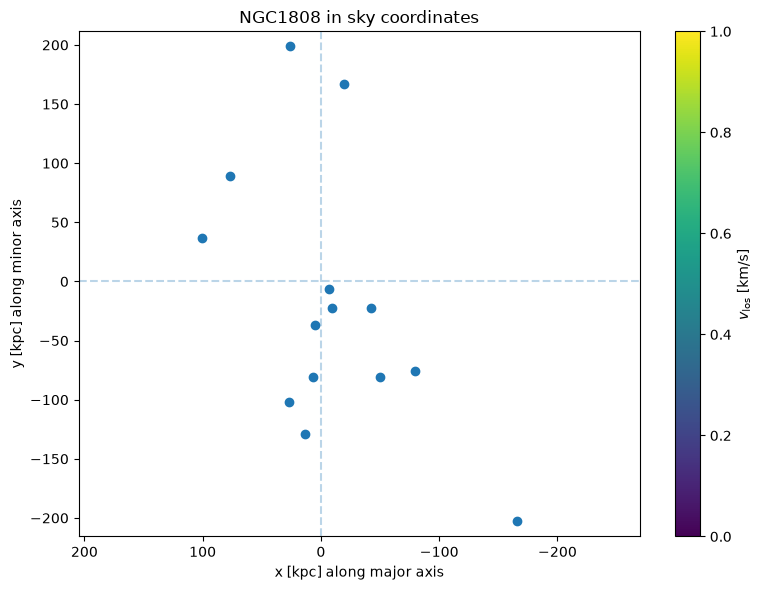

In [228]:
fig, ax = plt.subplots(figsize=(8,6))
t = ascii.read('elves_ps.mrt', format='mrt')

hostid = "NGC1808"
h    = t[t["Host"] == hostid]

sc = plt.scatter(h["x_kpc"], h["y_kpc"])
#plt.scatter(0, 0, marker="*", s=300, color="orange", zorder=4)
plt.axhline(0, ls="--", alpha=0.3)
plt.axvline(0, ls="--", alpha=0.3)
plt.colorbar(sc, ax=ax, label="$v_{\\rm los}$ [km/s]")
ax.invert_xaxis()
plt.xlabel("x [kpc] along major axis")
plt.ylabel("y [kpc] along minor axis")
plt.title(f"{hostid} in sky coordinates")
plt.axis("equal")
plt.tight_layout()
plt.show()